# <p style="background-color:#5A0E24;font-family:newtimeroman;color:#FFF9ED;font-size:90%;text-align:center;border-radius:10px; border: 2px solidrgb(98, 0, 255); padding: 10px;"> TrashNet </p>


## Image Classification task
## Classes:


  - **Plastic**
  - **cardboard**
  - **Glass**

# Libraries

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import random
import seaborn as sns
import keras
import tensorflow as tf
import zipfile
import warnings
from keras import (
    callbacks, layers, metrics,
    models, utils
)
from pathlib import Path
from keras.layers import BatchNormalization
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from collections import Counter
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
warnings.filterwarnings('ignore')

In [ ]:
SEED = 42
ENABLE_DETERMINISM = True
keras.utils.set_random_seed(SEED)
if ENABLE_DETERMINISM:
    tf.config.experimental.enable_op_determinism()

# Downloading data

In [ ]:
!kaggle datasets download -d sharmajhalak/trashnet

Dataset URL: https://www.kaggle.com/datasets/sharmajhalak/trashnet
License(s): unknown
100% 19.9M/19.9M [00:02<00:00, 10.1MB/s]



In [ ]:
with zipfile.ZipFile("/content/trashnet.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/trashnet")

In [ ]:
train_dir = Path("/content/trashnet/train")
test_dir = Path("/content/trashnet/valid")

- since there is no test file so i decided to split the train file into train val and use the val file to test

# Analysis & Preprocessing

## Corrupted images

In [ ]:
def get_corrupted_images(data_dir: Path) -> list[Path]:
    corrupted = []

    for class_name in os.listdir(data_dir):
        class_dir = data_dir / class_name

        for img_name in os.listdir(class_dir):
            img_path = class_dir / img_name

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except:
                corrupted.append(img_path);

    return corrupted

corrupted_images = []
for dir in [train_dir, test_dir]:
    corrupted_images += get_corrupted_images(dir)
print(f"[BEFORE DELETION] Corrupted images count: {len(corrupted_images)}")

if len(corrupted_images) == 0:
    print("\nNo corrupted images found!")

else:
    for img_path in corrupted_images:
        os.remove(img_path)

    corrupted_images = []
    for dir in [train_dir, test_dir]:
        corrupted_images += get_corrupted_images(dir)
    print(f"[AFTER  DELETION] Corrupted images count: {len(corrupted_images)}")

[BEFORE DELETION] Corrupted images count: 0

No corrupted images found!


## Color modes and formats

In [ ]:
def check_formats_and_modes(data_dir: Path) -> tuple[set[str], set[str]]:
    img_formats = set()
    color_modes = set()

    for class_name in os.listdir(data_dir):
        class_dir = data_dir / class_name

        for img_name in os.listdir(class_dir):
            img_path = class_dir / img_name

            img_formats.add(img_path.suffix)
            color_modes.add(Image.open(img_path).mode)

    return img_formats, color_modes

img_formats = set()
color_modes = set()
for dir in [train_dir, test_dir]:
    formats, modes = check_formats_and_modes(dir)
    img_formats |= formats
    color_modes |= modes

print(f"Image Formats: {img_formats}")
print(f"Color Modes: {color_modes}")

Image Formats: {'.jpg'}
Color Modes: {'RGB'}


## plot samples from each class

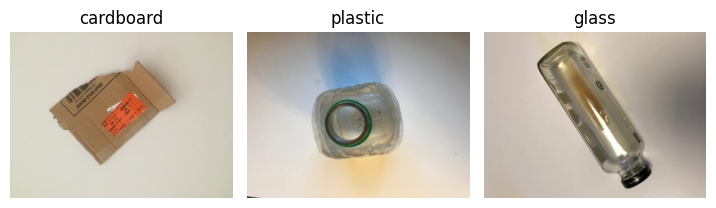

In [ ]:
classes = os.listdir(train_dir)
plt.figure(figsize=(12, 7))
for i, cls in enumerate(classes):
    class_dir = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_dir))
    img_path = os.path.join(class_dir, img_name)
    img = Image.open(img_path)

    plt.subplot(2, 5,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

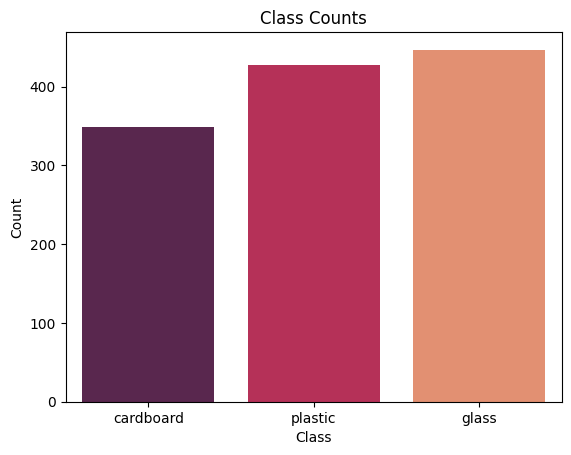

In [ ]:
cc = {}
for c in classes:
    cc[c] = len(os.listdir(train_dir / c))
sns.barplot(x=list(cc.keys()), y=list(cc.values()),palette='rocket')
plt.title("Class Counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [ ]:
cc

{'cardboard': 349, 'plastic': 428, 'glass': 447}

In [ ]:
cc = {}
for c in classes:
    cc[c] = len(os.listdir(test_dir / c))
cc

{'cardboard': 54, 'plastic': 54, 'glass': 54}

## Image size

In [ ]:
def check_image_sizes(data_dir, num_samples=50):
    sizes = []

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)

        images = os.listdir(cls_path)
        sample_images = random.sample(images, min(num_samples, len(images)))

        for img_name in sample_images:
            img_path = os.path.join(cls_path, img_name)

            try:
                with Image.open(img_path) as img:
                    sizes.append(img.size)
            except:
                pass
    return sizes

sizes = check_image_sizes(train_dir)
unique_sizes = set(sizes)

print("Unique image sizes found:", unique_sizes)

Unique image sizes found: {(512, 384)}


## Insights

- Dataset consists of three classes [ plastic , cardboard , glass ]

- the diffrence between samples in the classes in training set is small --> no class imbalance
- no. of samples in each class in the test set is 54
- no corrupted images
- all the images with format `jpg` , color mode `RGB`
- dimensions (512, 384 ) for all images --> need resize

# 1#

## Split Data


In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds =utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

Found 1224 files belonging to 3 classes.
Using 980 files for training.
Found 1224 files belonging to 3 classes.
Using 244 files for validation.
Found 162 files belonging to 3 classes.


In [ ]:
tc=Counter()
vc=Counter()
for images, labels in train_ds:
    tc.update(labels.numpy())
for images, labels in val_ds:
    vc.update(labels.numpy())
print(tc)
print(vc)

Counter({np.int32(1): 360, np.int32(2): 334, np.int32(0): 286})
Counter({np.int32(2): 244})


- this splt causes weird results as the val contain only one class so i will try stratified split

In [ ]:
classes=['plastic','cardboard','glass']
img_paths=[]
img_labels=[]
for cls in classes:
    class_dir = os.path.join(train_dir, cls)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        img_paths.append(img_path)
        img_labels.append(cls)

x_train, x_val, y_train, y_val = train_test_split(img_paths, img_labels, test_size=0.2, random_state=42, stratify=img_labels)

In [ ]:
print(Counter(y_train))
print(Counter(y_val))

Counter({'glass': 358, 'plastic': 342, 'cardboard': 279})
Counter({'glass': 89, 'plastic': 86, 'cardboard': 70})


In [ ]:
map_dict = {'cardboard': 0, 'glass': 1, 'plastic': 2} # mapping as the test dir
y_train = [map_dict[label] for label in y_train]
y_val = [map_dict[label] for label in y_val]

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))

In [ ]:
def img_preprocess(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

train_ds = train_ds.map(img_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(img_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
tc=Counter()
vc=Counter()
for images, labels in train_ds:
    tc.update(labels.numpy())
for images, labels in val_ds:
    vc.update(labels.numpy())
print(tc)
print(vc)

Counter({np.int32(1): 358, np.int32(2): 342, np.int32(0): 279})
Counter({np.int32(1): 89, np.int32(2): 86, np.int32(0): 70})


## Custom CNN Model Builder


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
def build_model(input_shape=(128,128,3), num_classes=3):

    inputs = layers.Input(shape=input_shape)
    x = inputs
    x=layers.Rescaling(1./255)(x)
    x=data_augmentation(x)
    # CNN
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    # FC
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

model = build_model()
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,067 (16.36 MB)

 Trainable params: 4,288,067 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=["accuracy"])

In [ ]:
#callbacks=EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
callbacks=ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

### Model Fitting

In [ ]:
history = model.fit(train_ds, validation_data=val_ds, epochs=30,callbacks=callbacks)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.4229 - loss: 1.1446 - val_accuracy: 0.6367 - val_loss: 0.9111 - learning_rate: 0.0010
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5403 - loss: 0.9092 - val_accuracy: 0.6327 - val_loss: 0.8317 - learning_rate: 0.0010
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6272 - loss: 0.8241 - val_accuracy: 0.7061 - val_loss: 0.7549 - learning_rate: 0.0010
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6547 - loss: 0.7677 - val_accuracy: 0.6653 - val_loss: 0.6782 - learning_rate: 0.0010
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6384 - loss: 0.8019 - val_accuracy: 0.6653 - val_loss: 0.7113 - learning_rate: 0.0010
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6190 - loss: 0.8227 - val_accuracy: 0.6286 - val_loss: 0.7138 - learning_rate: 0.0010
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.6190 - loss: 0.8003 - val_acc

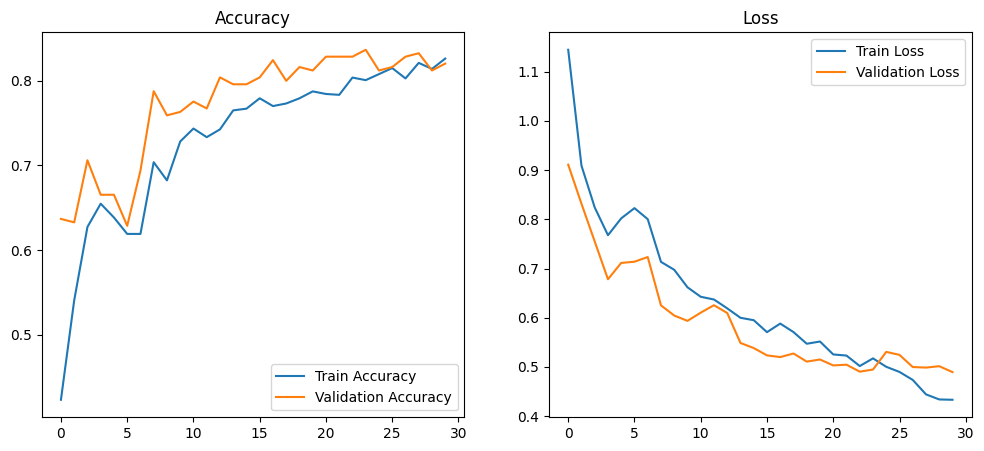

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc,label="Train Accuracy")
plt.plot(val_acc,label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(loss,label="Train Loss")
plt.plot(val_loss,label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.show()

### Model Evaluation

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
  predictions = model.predict(images, verbose=0)

  y_true.extend(labels.numpy())
  y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
class_names = ["cardboard", "glass", "plastic"]
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

   cardboard       0.98      0.87      0.92        54
       glass       0.78      0.78      0.78        54
     plastic       0.73      0.81      0.77        54

    accuracy                           0.82       162
   macro avg       0.83      0.82      0.82       162
weighted avg       0.83      0.82      0.82       162



In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8210 - loss: 0.5028
Test Loss: 0.5027719140052795
Test Accuracy: 0.8209876418113708


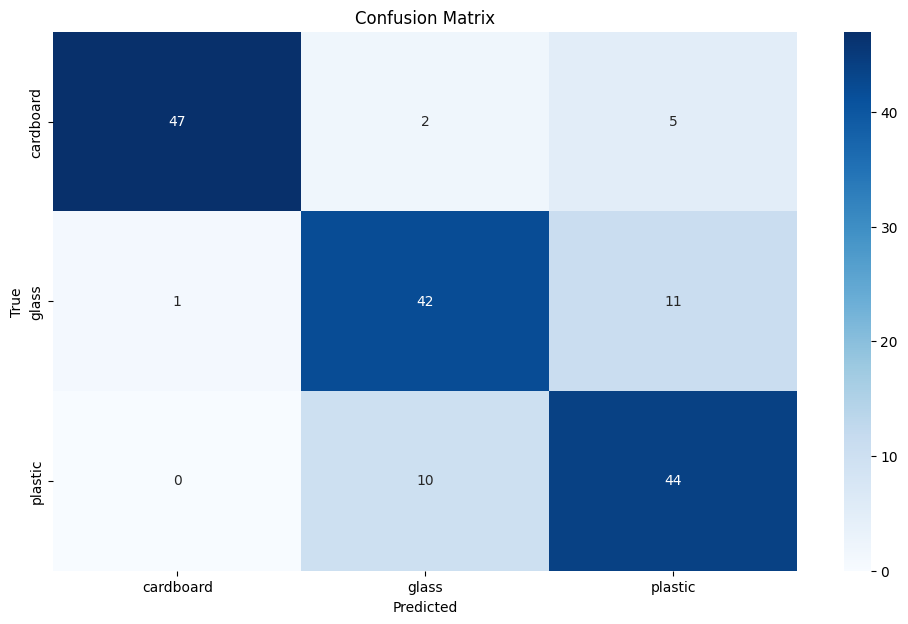

In [ ]:
cm=confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 7))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

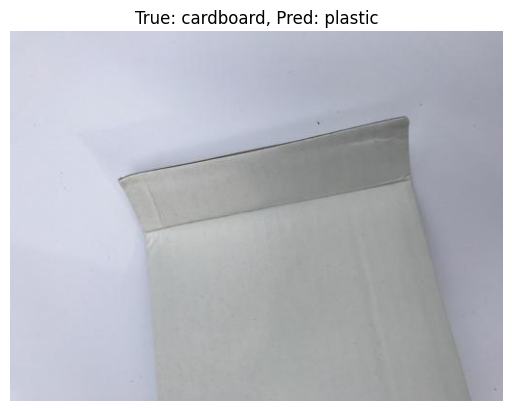

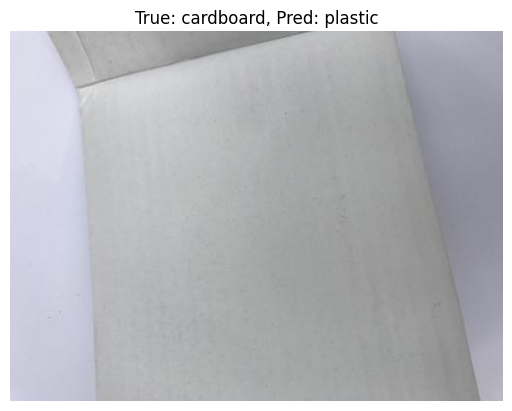

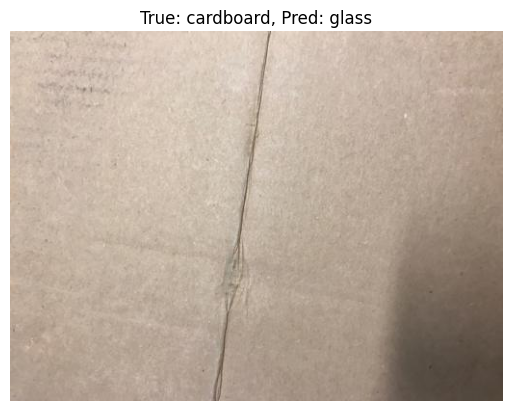

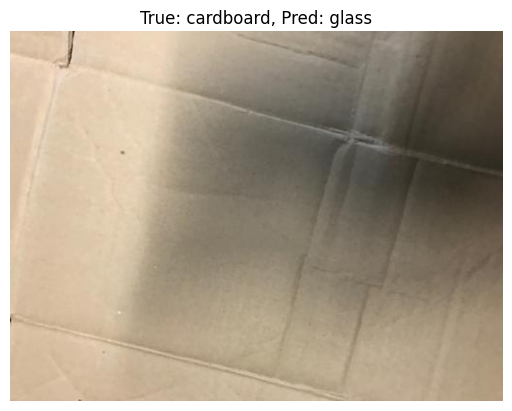

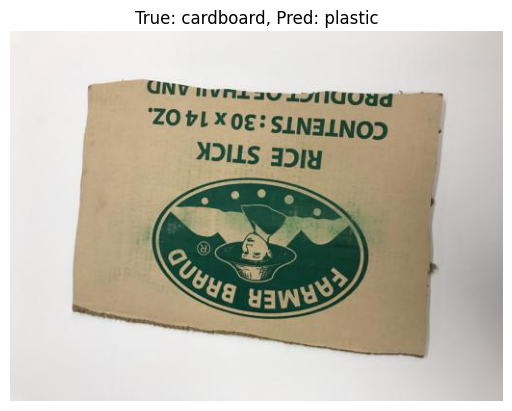

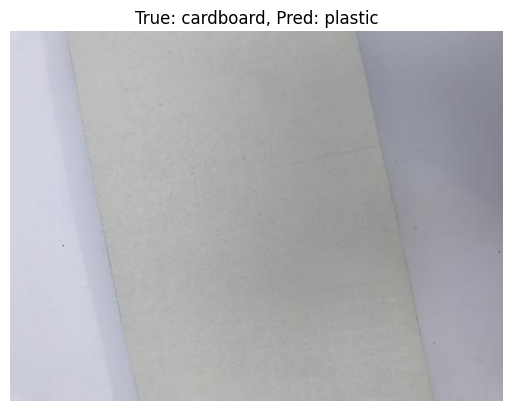

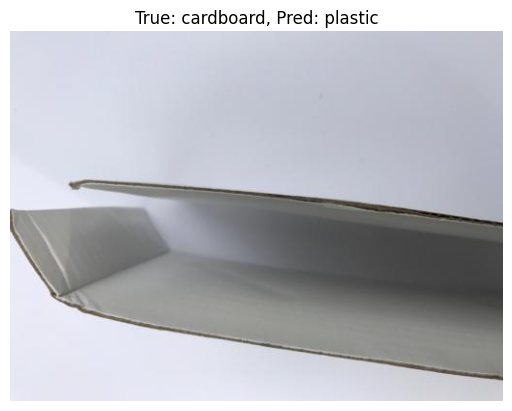

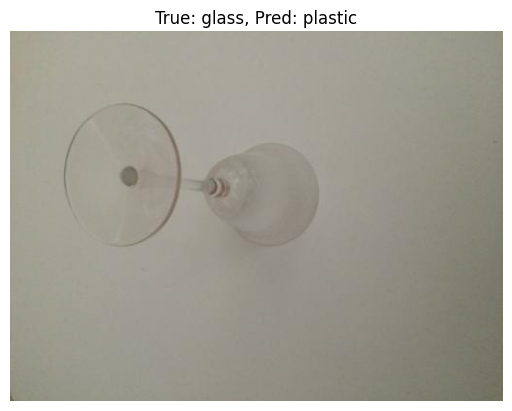

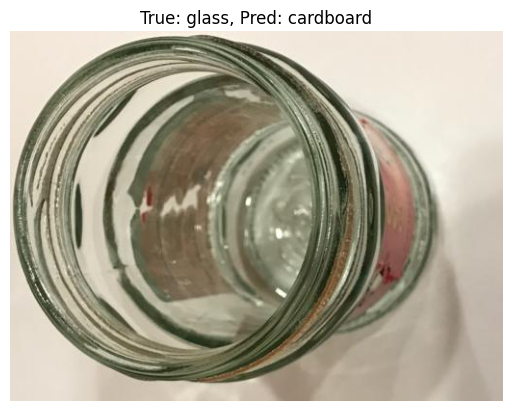

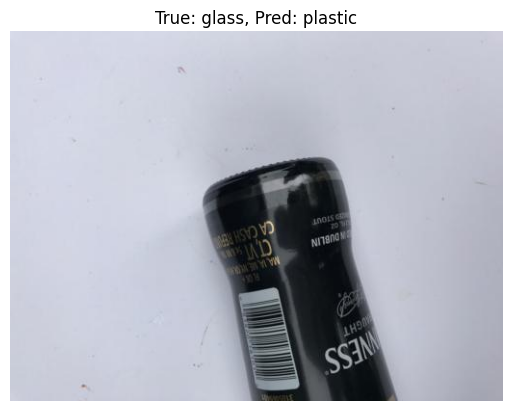

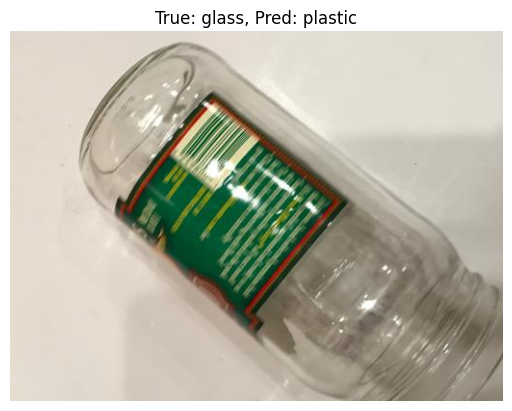

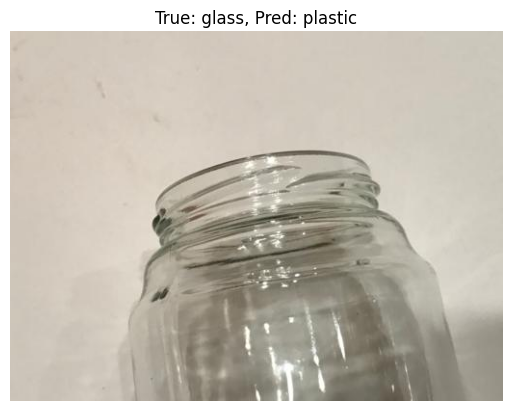

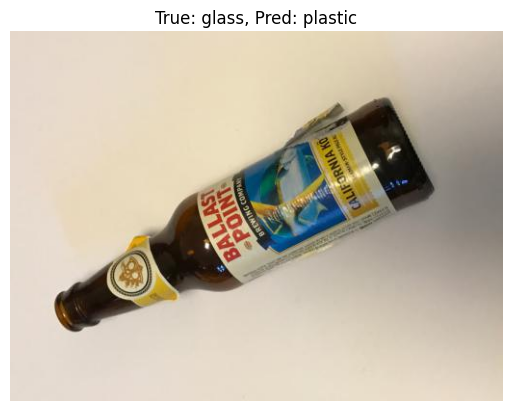

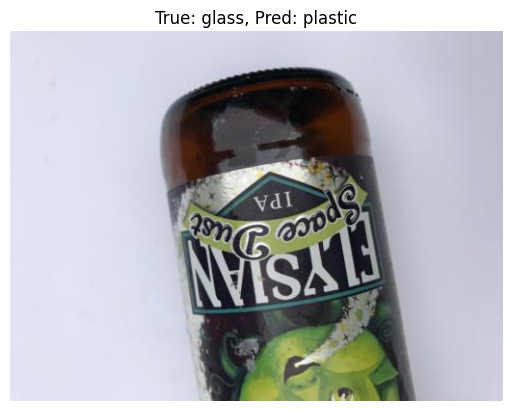

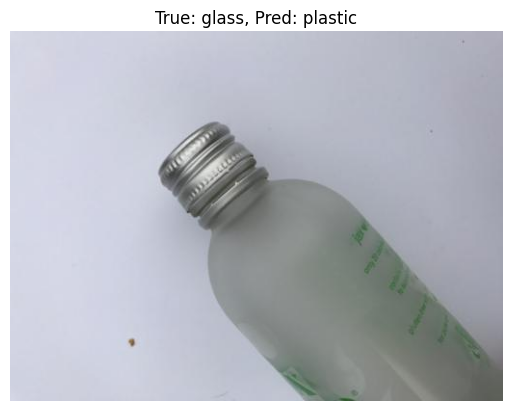

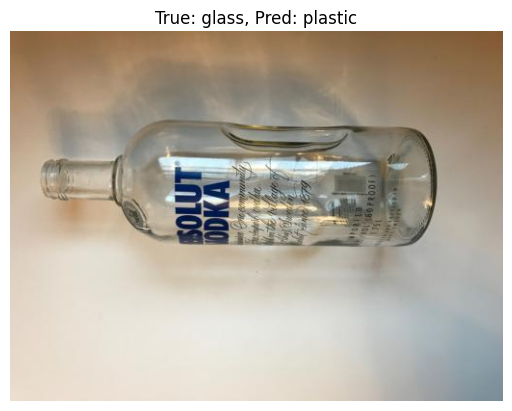

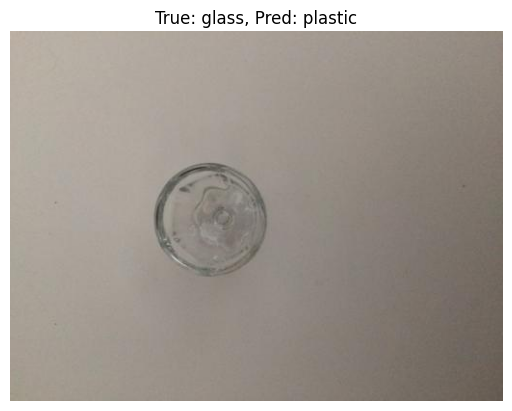

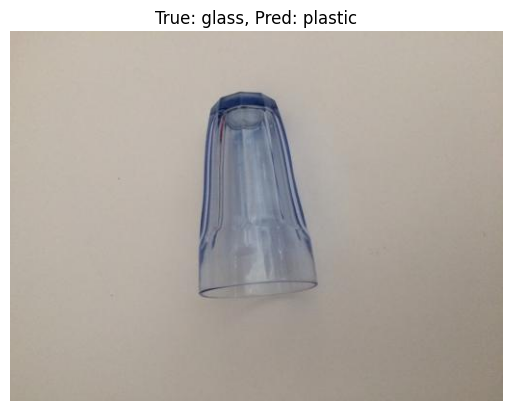

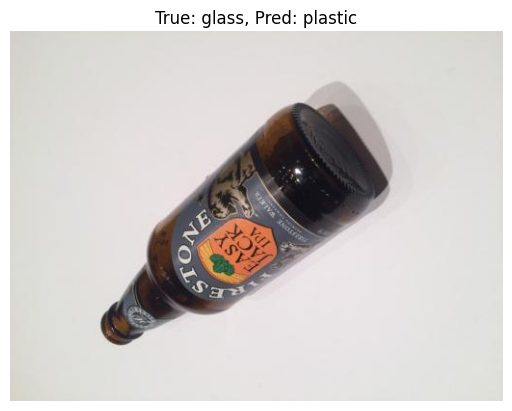

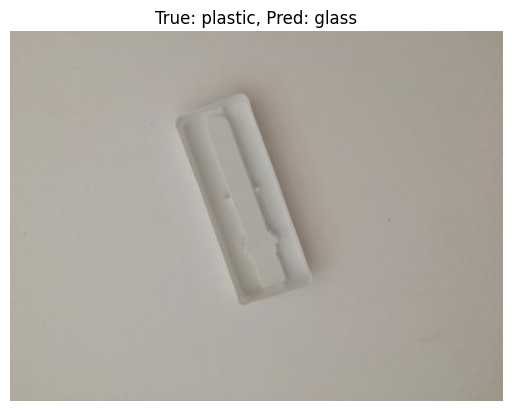

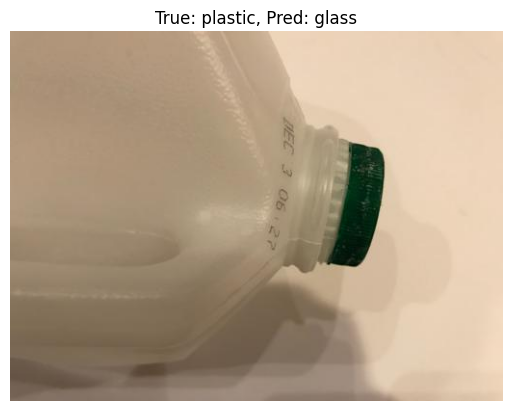

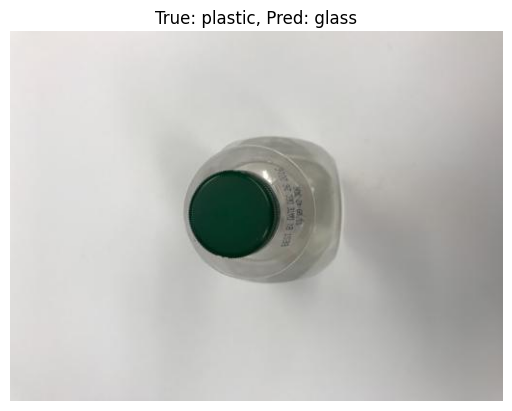

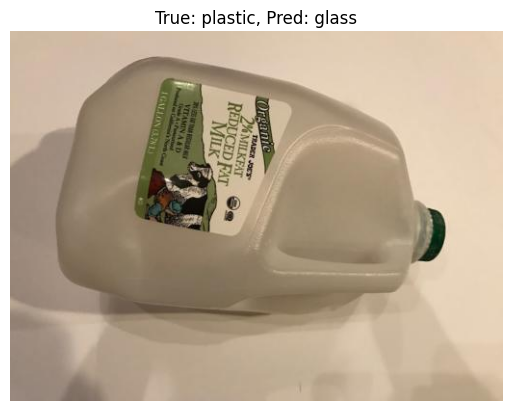

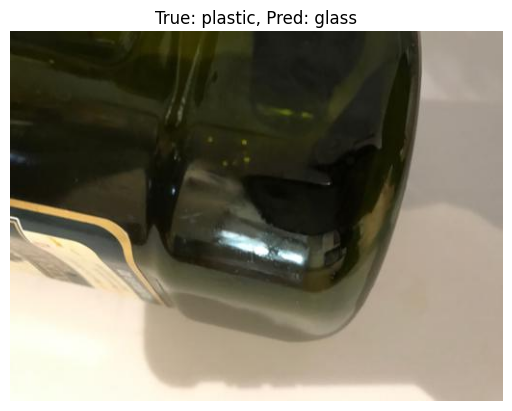

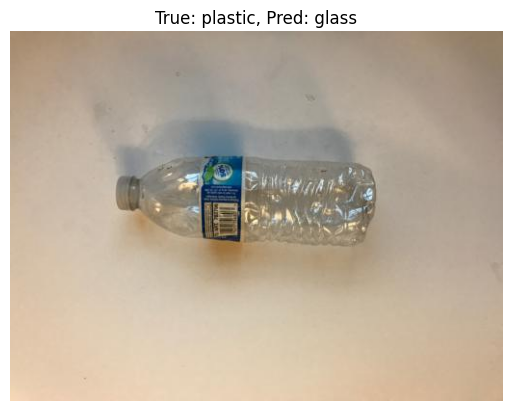

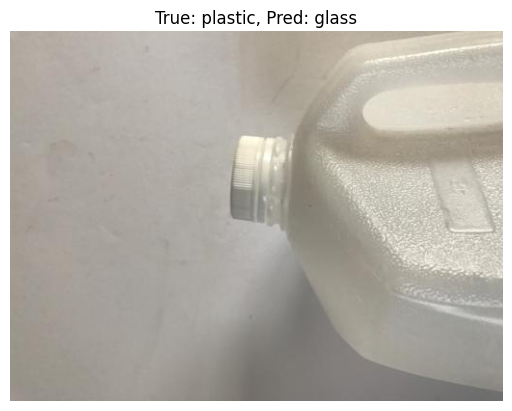

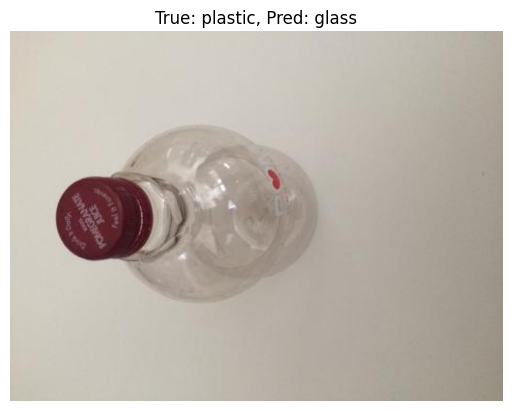

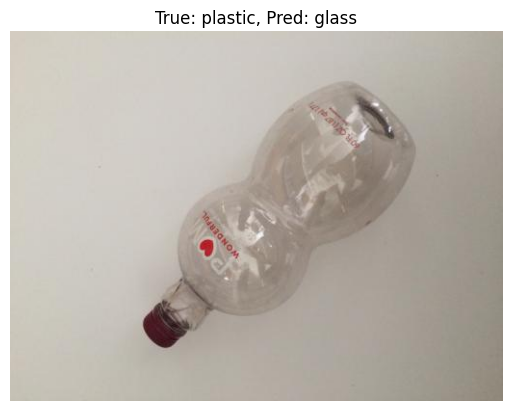

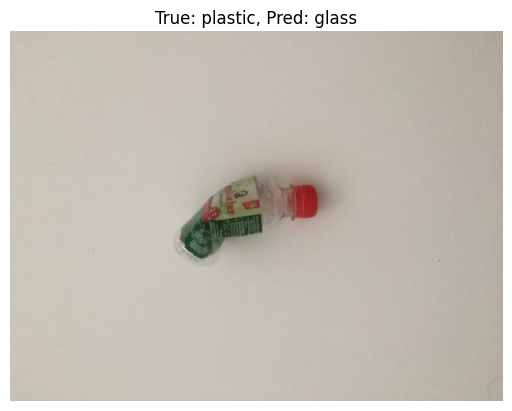

In [ ]:
for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        img_path = test_ds.file_paths[i]
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"True: {class_names[y_true[i]]}, Pred: {class_names[y_pred[i]]}")
        plt.axis("off")
        plt.show()

# 2#

## Split Data

In [ ]:
IMG_SIZE = (384,512)
BATCH_SIZE = 32
SEED = 42

test_ds = utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

Found 162 files belonging to 3 classes.


In [ ]:
classes=['plastic','cardboard','glass']
img_paths=[]
img_labels=[]
for cls in classes:
    class_dir = os.path.join(train_dir, cls)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        img_paths.append(img_path)
        img_labels.append(cls)

x_train, x_val, y_train, y_val = train_test_split(img_paths, img_labels, test_size=0.2, random_state=42, stratify=img_labels)

In [ ]:
map_dict = {'cardboard': 0, 'glass': 1, 'plastic': 2} # mapping as the test dir
y_train = [map_dict[label] for label in y_train]
y_val = [map_dict[label] for label in y_val]

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))

In [ ]:
train_ds = train_ds.map(img_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(img_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## Custom CNN Model Builder

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])
   # layers.RandomRotation(0.15),
   # layers.RandomZoom(0.15),
   # layers.RandomContrast(0.05)
   # layers.RandomBrightness(0.2)

In [ ]:
def build_model(input_shape=(384,512,3), num_classes=3):

    inputs = layers.Input(shape=input_shape)
    x = inputs
    x=layers.Rescaling(1./255)(x)
    x=data_augmentation(x)
    # CNN
    x = layers.Conv2D(32, (3,3), padding='same')(x)
   # x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3,3), padding='same')(x)
   # x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3,3), padding='same')(x)
  #  x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    # FC
    x = layers.GlobalAveragePooling2D()(x)
   # x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

model = build_model()
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 384, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 384, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 384, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 384, 512, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 384, 512, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 192, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 192, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 192, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 96, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 96, 128, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 96, 128, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 48, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 48, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,699 (1.61 MB)

 Trainable params: 421,699 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=["accuracy"])

In [ ]:
callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)]

### Model fitting

In [ ]:
history = model.fit(train_ds, validation_data=val_ds, epochs=50,callbacks=callbacks)    #,class_weight=cw)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 247ms/step - accuracy: 0.4086 - loss: 1.0453 - val_accuracy: 0.5878 - val_loss: 0.8704 - learning_rate: 0.0010
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.5638 - loss: 0.8513 - val_accuracy: 0.6449 - val_loss: 0.7755 - learning_rate: 0.0010
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 217ms/step - accuracy: 0.5955 - loss: 0.8005 - val_accuracy: 0.7184 - val_loss: 0.7574 - learning_rate: 0.0010
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.5873 - loss: 0.8542 - val_accuracy: 0.6163 - val_loss: 0.8732 - learning_rate: 0.0010
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 223ms/step - accuracy: 0.5761 - loss: 0.8490 - val_accuracy: 0.5469 - val_loss: 0.9043 - learning_rate: 0.0010
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.6404 - loss: 0.7809 - val_accuracy: 0.6490 - val_loss: 0.6900 - learning_rate: 0.0010
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 225ms/step - accuracy: 0.6425 - loss: 0.7780 -

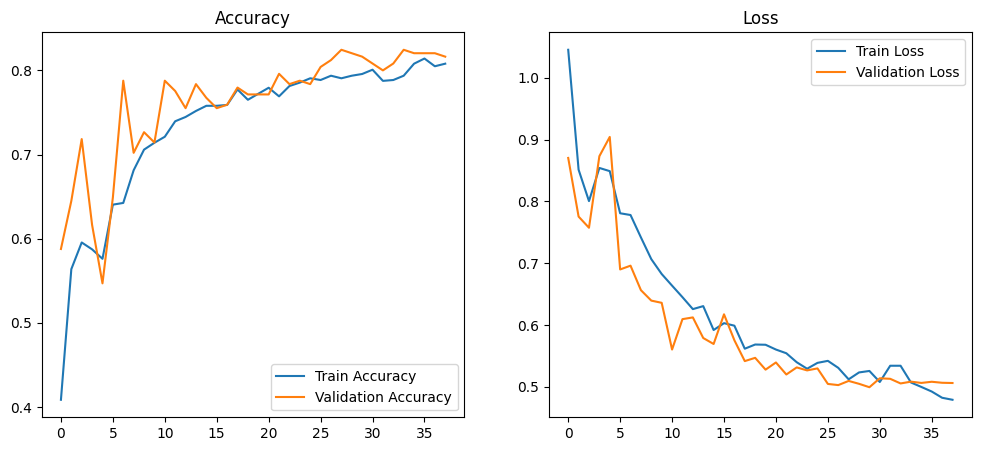

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc,label="Train Accuracy")
plt.plot(val_acc,label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(loss,label="Train Loss")
plt.plot(val_loss,label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.show()

### Model Evaluation

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
  predictions = model.predict(images, verbose=0)

  y_true.extend(labels.numpy())
  y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

   cardboard       0.94      0.81      0.87        54
       glass       0.73      0.85      0.79        54
     plastic       0.79      0.76      0.77        54

    accuracy                           0.81       162
   macro avg       0.82      0.81      0.81       162
weighted avg       0.82      0.81      0.81       162



In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8086 - loss: 0.5310
Test Loss: 0.5310432314872742
Test Accuracy: 0.8086419701576233


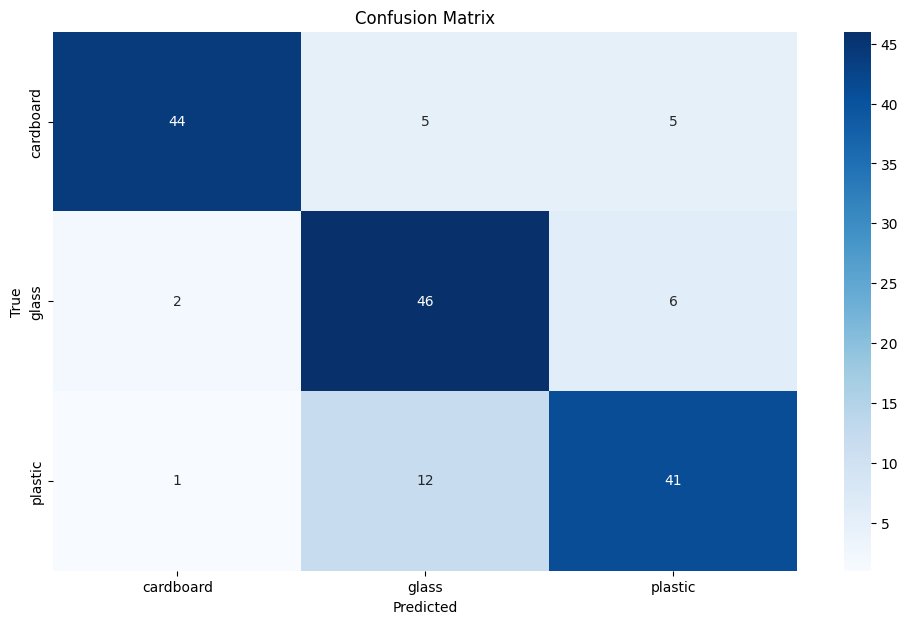

In [ ]:
cm=confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 7))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 3#

## Split Data

In [ ]:
IMG_SIZE = (175, 175)
BATCH_SIZE = 32
SEED = 42

test_ds = utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


Found 162 files belonging to 3 classes.


In [ ]:
classes=['plastic','cardboard','glass']
img_paths=[]
img_labels=[]
for cls in classes:
    class_dir = os.path.join(train_dir, cls)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        img_paths.append(img_path)
        img_labels.append(cls)

x_train, x_val, y_train, y_val = train_test_split(img_paths, img_labels, test_size=0.2, random_state=42, stratify=img_labels)

In [ ]:
map_dict = {'cardboard': 0, 'glass': 1, 'plastic': 2} # mapping as the test dir
y_train = [map_dict[label] for label in y_train]
y_val = [map_dict[label] for label in y_val]

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))

In [ ]:
train_ds = train_ds.map(img_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(img_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## CNN

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
def build_model(input_shape=(175,175,3), num_classes=3):

    inputs = layers.Input(shape=input_shape)
    x = inputs
    x=layers.Rescaling(1./255)(x)
    x=data_augmentation(x)
    # CNN
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
   # x = layers.BatchNormalization()(x)

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    # FC
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

model = build_model()
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 175, 175, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 175, 175, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 175, 175, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 175, 175, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 87, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 43, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 21, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 56448)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     7,225,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,319,107 (27.92 MB)

 Trainable params: 7,319,107 (27.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=["accuracy"])

In [ ]:
callbacks=ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

In [ ]:
history = model.fit(train_ds, validation_data=val_ds, epochs=50,callbacks=callbacks)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.3922 - loss: 1.3369 - val_accuracy: 0.4776 - val_loss: 0.9660 - learning_rate: 0.0010
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.5424 - loss: 0.8914 - val_accuracy: 0.6939 - val_loss: 0.7453 - learning_rate: 0.0010
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.6251 - loss: 0.8197 - val_accuracy: 0.7184 - val_loss: 0.7265 - learning_rate: 0.0010
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.6507 - loss: 0.7796 - val_accuracy: 0.7469 - val_loss: 0.6645 - learning_rate: 0.0010
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.6823 - loss: 0.7424 - val_accuracy: 0.7755 - val_loss: 0.6464 - learning_rate: 0.0010
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.6885 - loss: 0.7112 - val_accuracy: 0.7714 - val_loss: 0.5775 - learning_rate: 0.0010
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.6987 - loss: 0.6934 - val_acc

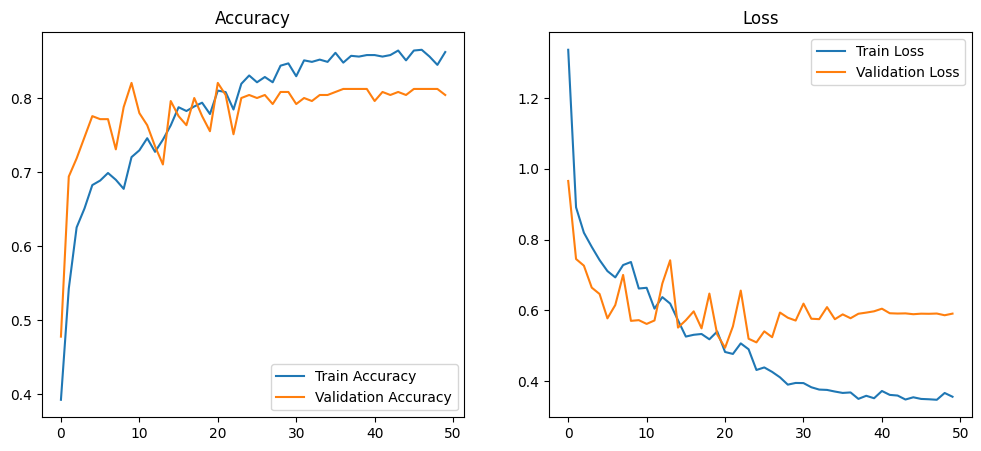

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc,label="Train Accuracy")
plt.plot(val_acc,label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(loss,label="Train Loss")
plt.plot(val_loss,label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.show()

### Model Evaluate

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
  predictions = model.predict(images, verbose=0)

  y_true.extend(labels.numpy())
  y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

   cardboard       1.00      0.91      0.95        54
       glass       0.84      0.69      0.76        54
     plastic       0.70      0.89      0.78        54

    accuracy                           0.83       162
   macro avg       0.85      0.83      0.83       162
weighted avg       0.85      0.83      0.83       162



In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8272 - loss: 0.5164
Test Loss: 0.5164042711257935
Test Accuracy: 0.8271604776382446


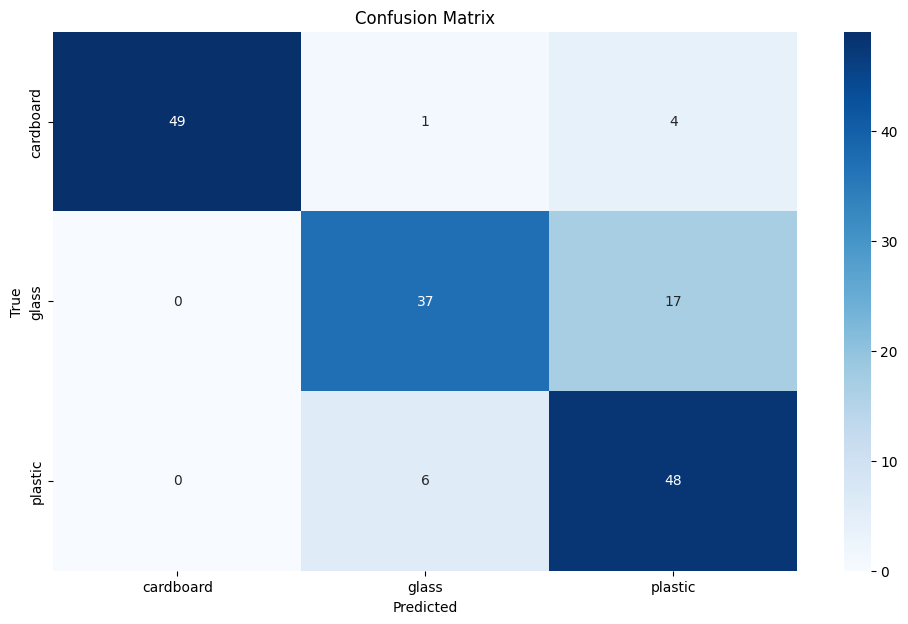

In [ ]:
cm=confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 7))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()